Here's the first script of the project, we test pulling one week of pricing data for germany. With the ensoe library, we can just use the code "DE_LU" for the market instead of the more complicated codes involved in the api. 

In [1]:
#remember to make sure you have the entsoe-py library installed. You can do this by running pip install entsoe-py in your terminal.
from dotenv import load_dotenv
import os
from entsoe import EntsoePandasClient
import pandas as pd

load_dotenv()  # reads .env and loads its variables into the environment, for this to work you need to have a .env file in the same directory as this script with the line: ENTSOE_API_KEY=your_api_key_here

#Below is the API call to get the day-ahead prices for Germany and Luxembourg (DE_LU) for the first week of January 2026.
client = EntsoePandasClient(api_key=os.environ["ENTSOE_API_KEY"])

start = pd.Timestamp('2026-01-01', tz='Europe/Berlin')
end   = pd.Timestamp('2026-01-08', tz='Europe/Berlin')

# Below is the actual call

de_prices = client.query_day_ahead_prices('DE_LU', start=start, end=end)
print(de_prices.head())

2026-01-01 00:00:00+01:00    63.64
2026-01-01 00:15:00+01:00    61.48
2026-01-01 00:30:00+01:00    58.00
2026-01-01 00:45:00+01:00    49.99
2026-01-01 01:00:00+01:00    60.01
dtype: float64


ok so we seem to get a series rather than a data frame, cool cool. But it works! 

In [2]:
de_prices.info()

<class 'pandas.Series'>
DatetimeIndex: 673 entries, 2026-01-01 00:00:00+01:00 to 2026-01-08 00:00:00+01:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
673 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB


In [3]:
de_prices

2026-01-01 00:00:00+01:00    63.64
2026-01-01 00:15:00+01:00    61.48
2026-01-01 00:30:00+01:00    58.00
2026-01-01 00:45:00+01:00    49.99
2026-01-01 01:00:00+01:00    60.01
                             ...  
2026-01-07 23:00:00+01:00    95.11
2026-01-07 23:15:00+01:00    89.01
2026-01-07 23:30:00+01:00    86.83
2026-01-07 23:45:00+01:00    84.10
2026-01-08 00:00:00+01:00    86.88
Length: 673, dtype: float64

lets try south swedish prices, pricing zone 4

In [4]:
se_prices = client.query_day_ahead_prices('SE_4', start=start, end=end)
se1_prices = client.query_day_ahead_prices('SE_1', start=start, end=end)
print(se_prices.head())

2026-01-01 00:00:00+01:00    41.58
2026-01-01 00:15:00+01:00    40.87
2026-01-01 00:30:00+01:00    40.20
2026-01-01 00:45:00+01:00    39.23
2026-01-01 01:00:00+01:00    38.30
dtype: float64


success! Woop woop. Ok, now lets play with them.

Text(0.5, 1.0, 'Day-ahead prices, first week of Jan 2026')

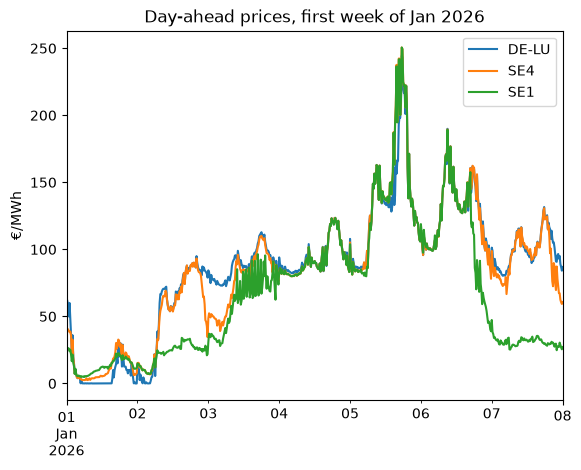

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

de_prices.plot(ax=plt.gca(), label='DE-LU')
se_prices.plot(ax=plt.gca(), label='SE4')
se1_prices.plot(ax=plt.gca(), label='SE1')
plt.legend()
plt.ylabel('€/MWh')
plt.title('Day-ahead prices, first week of Jan 2026')

Ok this all takes a lot of time, here's a test to see how long:

In [ ]:
"""import time
t0 = time.time()
de_prices = client.query_day_ahead_prices('DE_LU', start=start, end=end)
print(f"{time.time() - t0:.1f}s")"""

32.1s


All right, lets try to pull the generation data for say, germany. The nett=True is to avoid the multi-index in column names denoting basically water pumping as consuption. We dont need that, and it complicates our pivot later, better deal with it now.

In [10]:
de_gen = client.query_generation('DE_LU', start=start, end=end, nett=True)
de_gen.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
2026-01-01 00:00:00+01:00,4210.669292,4364.73245,562.04667,6662.260660,4729.875683,395.34600,34.79172,352.8485,978.01191,15.3520,219.03346,84.343444,17.807900,674.123000,2832.919,32324.420908
2026-01-01 00:15:00+01:00,4219.440200,4021.99555,621.40334,6381.432660,4556.335678,395.32000,34.84380,601.6666,960.89287,19.1100,219.10446,84.727624,15.318052,669.431000,3178.024,32723.664520
2026-01-01 00:30:00+01:00,4204.712552,3816.62234,623.93333,6215.596999,4425.860408,395.58000,34.73164,-95.2674,981.17837,42.9920,218.87846,84.729628,15.274152,665.872999,3234.816,33610.820868
2026-01-01 00:45:00+01:00,4183.863608,3587.41778,596.95999,6134.690650,4410.482520,395.45333,34.76356,74.5468,1013.05017,68.4980,219.16746,84.478300,14.816540,674.296000,3401.854,34111.118520
2026-01-01 01:00:00+01:00,4157.940284,3125.83925,583.98333,5853.217000,4419.183129,395.58000,34.67276,326.6449,987.53957,66.6149,219.14246,84.306628,15.297652,658.180999,3729.761,34408.820148


In [11]:
se4_gen = client.query_generation('SE_4', start=start, end=end, nett=True)
se4_gen.head()

,Fossil Gas,Hydro Water Reservoir,Other,Solar,Wind Onshore
2026-01-01 00:00:00+01:00,0.3,119.641,147.193,0.041,825.139
2026-01-01 00:15:00+01:00,0.3,119.639,137.853,0.042,858.453
2026-01-01 00:30:00+01:00,0.3,117.851,128.894,0.042,892.935
2026-01-01 00:45:00+01:00,0.3,114.545,123.263,0.041,922.501
2026-01-01 01:00:00+01:00,0.2,80.413,129.910,0.041,1008.677


Ok here we see already an issue with the data format - concating these dataframes will give us LOTS of nulls. Instead we pivot and remove the problem that way. We need some pivoting coding with .melt.

In [ ]:
def to_long(gen_df, zone):
    long = (
        gen_df.rename_axis("timestamp")
        .reset_index()
        .melt(id_vars="timestamp", var_name="production_type", value_name="value_mw")
    )
    long["zone"] = zone
    return long[["zone", "timestamp", "production_type", "value_mw"]]

de_long = to_long(de_gen, "DE_LU")
se4_long = to_long(se4_gen, "SE_4")

generation_long = pd.concat([de_long, se4_long], ignore_index=True)
generation_long.head()

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['timestamp']"